# RouteZone — Notebook 06 : Modélisation V2 (Haversine)

---

| | |
|---|---|
| **Candidate** | Meriem Abdelouahed |
| **Formation** | Développeur en Intelligence Artificielle — Simplon x Microsoft |
| **Certification** | RNCP37827 |
| **Projet** | RouteZone — Prédiction de gravité des accidents routiers |
| **Notebook** | 06 / 08 — Modélisation V2 : enrichissement features Haversine |

---

## Sommaire

1. [Imports et configuration](#1-imports)
2. [Préparation des données — features V2](#2-donnees)
3. [Veille stratégique — 6 stratégies de déséquilibre](#3-veille)
4. [Entraînement final LightGBM](#4-final)
5. [Visualisations](#5-viz)
6. [Explicabilité SHAP](#6-shap)
7. [Calibration et sauvegarde](#7-calibration)
8. [Conclusion](#8-conclusion)

---

## Objectif et différences avec la V1

Le notebook 05 (V1) a posé la base : 3 modèles comparés, data leakage détecté et corrigé.
**Ce notebook apporte deux enrichissements par rapport à la V1 :**

| | V1 (notebook 05) | V2 (ce notebook) |
|---|---|---|
| Features | 25 (BAAC + météo) | **34** (+ 7 dérivées + 2 Haversine) |
| Temps intervention | ❌ absent | ✅ **Haversine** (distance vol d'oiseau × 1.3 à 60 km/h) |
| Stratégies déséquilibre | 1 testée (class_weight) | **6 comparées** |
| Optimisation | Paramètres par défaut | Paramètres par défaut |

**L'optimisation des hyperparamètres (Optuna, GridSearch) est réservée au notebook 08.**

---

### Rappel — Qu'est-ce que Haversine ?

Haversine est une formule mathématique qui calcule la **distance à vol d'oiseau**
entre deux points GPS (par exemple entre une caserne de pompiers et un accident).

```
temps (minutes) = distance_haversine (km) × 1.3 / 60 km/h × 60
```
- **× 1.3** : les routes font en moyenne 30% de détour par rapport à la ligne droite
- **/ 60 km/h** : vitesse moyenne estimée des secours

C'est une **approximation** — elle sera remplacée par les vrais temps OSRM dans le notebook 07.

**Compétences couvertes :** C8 (service IA), C9 (API IA)

<a id='1-imports'></a>
## 1. Imports et configuration

---

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import shap
from pathlib import Path
from datetime import datetime

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split, learning_curve
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    f1_score, recall_score, precision_score, precision_recall_curve
)
from sklearn.calibration import CalibratedClassifierCV
from imblearn.over_sampling import SMOTENC
from imblearn.under_sampling import RandomUnderSampler

import lightgbm as lgb
import mlflow
import mlflow.sklearn

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

ROOT        = Path('..').resolve()
DATA_PATH   = ROOT / 'data' / 'processed' / 'dataset_clean.csv'
INTERV_PATH = ROOT / 'data' / 'processed' / 'temps_intervention.csv'
MODELS_DIR  = ROOT / 'models'
MODELS_DIR.mkdir(exist_ok=True)
VIZ_DIR = Path('visualisations')
VIZ_DIR.mkdir(exist_ok=True)

mlflow.set_tracking_uri('mlruns')
mlflow.set_experiment('routezone_v2')

print('Imports OK')
print(f'DATA_PATH   : {DATA_PATH} — existe : {DATA_PATH.exists()}')
print(f'INTERV_PATH : {INTERV_PATH} — existe : {INTERV_PATH.exists()}')

Imports OK
DATA_PATH   : C:\Users\Utilisateur\Documents\routezone2\Routezone\data\processed\dataset_clean.csv — existe : True
INTERV_PATH : C:\Users\Utilisateur\Documents\routezone2\Routezone\data\processed\temps_intervention.csv — existe : True


> **Observation :**
> Par rapport au notebook 05, trois imports sont ajoutés :
> - `shap` : pour expliquer les prédictions feature par feature
> - `SMOTENC` / `RandomUnderSampler` : pour tester les 6 stratégies de déséquilibre
> - `CalibratedClassifierCV` : pour calibrer les probabilités (les rendre plus réalistes)
>
> **Note technique :** dans ce notebook, toutes les données sont gardées en **float**
> dès le départ — pas de conversion en type `category` pandas.
> On indique à LightGBM quelles colonnes sont catégorielles via le paramètre
> `categorical_feature` dans `.fit()`. C'est équivalent mais évite les conflits
> avec SHAP, la calibration et les autres bibliothèques.

<a id='2-donnees'></a>
## 2. Préparation des données — features V2

---

In [2]:
# ── Chargement et binarisation ───────────────────────────────────
df = pd.read_csv(DATA_PATH, low_memory=False)
df['target'] = df['grav'].map({1: 0, 4: 0, 2: 1, 3: 1})
df = df.dropna(subset=['target'])
df['target'] = df['target'].astype(int)
print(f'Dataset : {len(df):,} lignes')
print(f'PAS GRAVE : {(df["target"]==0).mean()*100:.1f}% | GRAVE : {(df["target"]==1).mean()*100:.1f}%')

Dataset : 413,570 lignes
PAS GRAVE : 82.6% | GRAVE : 17.4%


In [3]:
# ── Enrichissement Haversine (généré dans le notebook 04) ────────
if INTERV_PATH.exists():
    df_ti = pd.read_csv(INTERV_PATH).drop_duplicates(subset=['Num_Acc'], keep='first')
    key = 'Num_Acc' if 'Num_Acc' in df.columns else 'num_acc'
    df = df.merge(df_ti, left_on=key, right_on='Num_Acc', how='left')
    if 'temps_total_prise_en_charge' not in df.columns:
        col = 'temps_intervention_min' if 'temps_intervention_min' in df.columns else None
        df['temps_total_prise_en_charge'] = df[col] if col else np.nan
    nb = df['temps_total_prise_en_charge'].notna().sum()
    print(f'Haversine chargé : {nb:,}/{len(df):,} accidents enrichis ({nb/len(df)*100:.1f}%)')
else:
    print('! Fichier non trouvé — lancez le notebook 04 en premier')
    df['temps_total_prise_en_charge'] = np.nan

Haversine chargé : 413,570/413,570 accidents enrichis (100.0%)


In [4]:
# ── Feature engineering ───────────────────────────────────────────
def get_creneau(h):
    if pd.isna(h): return 2
    h = int(h)
    if 0 <= h <= 6: return 0
    elif 7 <= h <= 9: return 1
    elif 10 <= h <= 16: return 2
    elif 17 <= h <= 21: return 3
    else: return 4

df['creneau'] = df['heure'].apply(get_creneau)

if 'age' not in df.columns:
    df['age'] = df.apply(lambda r: int(r['an']) - int(r['an_nais'])
                         if pd.notna(r.get('an_nais')) else np.nan, axis=1)

df['age_tranche'] = df['age'].apply(
    lambda a: 0 if pd.notna(a) and a < 25 else
             (1 if pd.notna(a) and a < 45 else
             (2 if pd.notna(a) and a < 65 else 3))
)

if all(c in df.columns for c in ['jour', 'mois', 'an']):
    df['jour_semaine'] = df.apply(
        lambda r: datetime(int(r['an']), int(r['mois']), int(r['jour'])).weekday()
        if pd.notna(r['jour']) else 2, axis=1)
    df['is_weekend'] = (df['jour_semaine'] >= 5).astype(int)

df['vma_x_nuit']      = df['vma'].fillna(50) * (df['lum'].fillna(1) >= 3).astype(int)
df['jeune_2roues']    = ((df['age'].fillna(35) < 25) & (df['catv'].fillna(7).isin([2,30,31,32]))).astype(int)
df['pluie_x_surface'] = ((df['atm'].fillna(1).isin([2,3])) & (df['surf'].fillna(1).isin([2,3,4]))).astype(int)

for col in ['temperature', 'precipitation', 'windspeed']:
    if col not in df.columns: df[col] = np.nan

df['zone_blanche'] = (df['temps_total_prise_en_charge'] > 30).astype(int) \
    if df['temps_total_prise_en_charge'].notna().any() else 0

if 'int' in df.columns:
    df = df.rename(columns={'int': 'int_feat'})

print('Features créées : creneau, age_tranche, jour_semaine, is_weekend,',
      'vma_x_nuit, jeune_2roues, pluie_x_surface, zone_blanche')

Features créées : creneau, age_tranche, jour_semaine, is_weekend, vma_x_nuit, jeune_2roues, pluie_x_surface, zone_blanche


In [5]:
# ── Sélection des 34 features ─────────────────────────────────────
FEATURES = [
    'lum', 'agg', 'int_feat', 'atm', 'col', 'catr', 'circ', 'vosp',
    'prof', 'plan', 'surf', 'infra', 'situ', 'vma',
    'catu', 'sexe', 'trajet', 'secu1', 'catv', 'age', 'heure', 'mois',
    'temperature', 'precipitation', 'windspeed',
    'creneau', 'age_tranche', 'jour_semaine', 'is_weekend',
    'vma_x_nuit', 'jeune_2roues', 'pluie_x_surface',
    'temps_total_prise_en_charge', 'zone_blanche',
]
FEATURES = [f for f in FEATURES if f in df.columns]

# Liste des colonnes catégorielles — passée à LightGBM via categorical_feature
# On NE convertit PAS en type pandas 'category' — on garde tout en float
# pour éviter les conflits avec SHAP, calibration, etc.
CATEGORICAL = ['lum', 'agg', 'atm', 'col', 'catr', 'circ', 'vosp', 'prof', 'plan',
               'surf', 'infra', 'situ', 'catu', 'sexe', 'trajet', 'secu1', 'catv',
               'creneau', 'age_tranche', 'jour_semaine']
if 'int_feat' in FEATURES: CATEGORICAL.append('int_feat')
cat_actual = [c for c in CATEGORICAL if c in FEATURES]

# Split temporel
df_train = df[df['an'].isin([2022, 2023])].copy()
df_test  = df[df['an'] == 2024].copy()
print(f'Train (2022-2023) : {len(df_train):,} | Test (2024) : {len(df_test):,}')
print(f'{len(FEATURES)} features au total')

# Imputation safe — stats calculées sur le train uniquement
for col in FEATURES:
    fill_val = (df_train[col].mode().iloc[0] if col in cat_actual
                else df_train[col].median()) if df_train[col].notna().any() else 0
    df_train[col] = df_train[col].fillna(fill_val)
    df_test[col]  = df_test[col].fillna(fill_val)

# ── TOUT EN FLOAT — pas de type 'category' pandas ─────────────────
# LightGBM gère les catégorielles via categorical_feature=cat_actual dans .fit()
X_train_full = df_train[FEATURES].astype(float).copy()
y_train_full = df_train['target'].copy()
X_test       = df_test[FEATURES].astype(float).copy()
y_test       = df_test['target'].copy()

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, stratify=y_train_full, random_state=42
)
print(f'Train : {len(X_train):,} | Val : {len(X_val):,} | Test : {len(X_test):,}')
print(f'GRAVE train : {y_train.mean()*100:.1f}% | GRAVE test : {y_test.mean()*100:.1f}%')

Train (2022-2023) : 265,064 | Test (2024) : 148,506
34 features au total
Train : 225,304 | Val : 39,760 | Test : 148,506
GRAVE train : 17.6% | GRAVE test : 17.2%


> **Observation — Préparation V2 :**
>
> **Les 9 features supplémentaires par rapport à la V1 :**
> - `temps_total_prise_en_charge` : temps Haversine en minutes — **feature #1 en importance**
>   (confirmé par la suite). Le notebook 04 a prouvé qu'un temps élevé = plus de décès.
> - `zone_blanche` : vaut 1 si ce temps dépasse 30 minutes (seuil Golden Hour)
> - `creneau` : heure regroupée en 5 tranches — plus facile à interpréter que l'heure brute
> - `jeune_2roues` : 1 si conducteur < 25 ans sur moto/scooter — profil très accidentogène
> - `vma_x_nuit` : vitesse limite × indicateur nuit — capte le risque combiné
> - `pluie_x_surface` : pluie ET surface mouillée simultanément
> - `age_tranche`, `jour_semaine`, `is_weekend` : regroupements pour aider le modèle
>
> **Imputation safe :** stats calculées sur le train uniquement.
> Si on les calculait sur tout le dataset, le test influencerait le train — fuite d'information.

<a id='3-veille'></a>
## 3. Veille stratégique — 6 stratégies de déséquilibre

---

Le dataset est déséquilibré : ~17% GRAVE vs ~83% PAS GRAVE.
Sans traitement, le modèle prédit presque tout en PAS GRAVE — on rate les accidents graves.

On teste 6 approches avec les **mêmes paramètres de base** pour une comparaison équitable :

| # | Stratégie | Ce qu'elle fait |
|---|---|---|
| 1 | **Baseline** | Rien — résultat sans traitement |
| 2 | **class_weight='balanced'** | Pénalise plus les erreurs sur GRAVE |
| 3 | **scale_pos_weight** | Même idée, ratio PAS GRAVE / GRAVE |
| 4 | **SMOTE-NC** | Crée de faux exemples GRAVE |
| 5 | **Undersampling** | Supprime des exemples PAS GRAVE |
| 6 | **Threshold 0.35** | class_weight + seuil de décision abaissé |

In [6]:
def evaluate_strategy(name, X_tr, y_tr, X_te, y_te, extra_params=None, threshold=0.5):
    """Entraîne LightGBM avec une stratégie, évalue, logue dans MLflow."""
    params = {
        'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.05,
        'num_leaves': 63, 'subsample': 0.8, 'colsample_bytree': 0.8,
        'random_state': 42, 'verbosity': -1,
    }
    if extra_params: params.update(extra_params)
    model = lgb.LGBMClassifier(**params)
    # X_tr est déjà en float — on passe cat_actual pour que LightGBM
    # traite ces colonnes comme catégorielles sans changer leur type
    model.fit(X_tr, y_tr, categorical_feature=cat_actual)
    proba = model.predict_proba(X_te)[:, 1]
    pred  = (proba >= threshold).astype(int)
    metrics = {
        'recall_grave':    recall_score(y_te, pred),
        'precision_grave': precision_score(y_te, pred),
        'f1_macro':        f1_score(y_te, pred, average='macro'),
        'auc_roc':         roc_auc_score(y_te, proba),
        'threshold':       threshold,
    }
    with mlflow.start_run(run_name=name):
        mlflow.log_params({**params, 'strategy': name, 'threshold': threshold})
        mlflow.log_metrics(metrics)
    print(f'  {name:35s} | Recall={metrics["recall_grave"]:.3f} | Prec={metrics["precision_grave"]:.3f} | F1={metrics["f1_macro"]:.3f} | AUC={metrics["auc_roc"]:.3f}')
    return {**metrics, 'name': name, 'model': model, 'proba': proba}

print('=' * 90)
print('COMPARAISON DES 6 STRATÉGIES')
print('=' * 90)
results = []

results.append(evaluate_strategy('1_baseline', X_train, y_train, X_test, y_test))
results.append(evaluate_strategy('2_class_weight_balanced', X_train, y_train, X_test, y_test,
                                  extra_params={'class_weight': 'balanced'}))

ratio = (y_train == 0).sum() / (y_train == 1).sum()
results.append(evaluate_strategy('3_scale_pos_weight', X_train, y_train, X_test, y_test,
                                  extra_params={'scale_pos_weight': ratio}))

# SMOTE-NC — sur-échantillonnage pour données mixtes catégorielles/numériques
try:
    cat_indices = [FEATURES.index(c) for c in cat_actual if c in FEATURES]
    smote = SMOTENC(categorical_features=cat_indices, random_state=42, sampling_strategy=0.5)
    X_res, y_res = smote.fit_resample(X_train, y_train)  # X_train déjà en float
    X_res = pd.DataFrame(X_res, columns=FEATURES)
    print(f'  SMOTE-NC : {len(X_train):,} -> {len(X_res):,} lignes')
    results.append(evaluate_strategy('4_smote_nc_0.5', X_res, y_res, X_test, y_test))
except Exception as e:
    print(f'  ! SMOTE-NC : {e}')

# Undersampling — supprime des exemples PAS GRAVE
try:
    rus = RandomUnderSampler(random_state=42, sampling_strategy=0.5)
    X_u, y_u = rus.fit_resample(X_train, y_train)
    X_u = pd.DataFrame(X_u, columns=FEATURES)
    print(f'  Undersampling : {len(X_train):,} -> {len(X_u):,} lignes')
    results.append(evaluate_strategy('5_undersampling_0.5', X_u, y_u, X_test, y_test))
except Exception as e:
    print(f'  ! Undersampling : {e}')

results.append(evaluate_strategy('6_balanced+threshold_0.35', X_train, y_train, X_test, y_test,
                                  extra_params={'class_weight': 'balanced'}, threshold=0.35))

print('\nEnregistré dans MLflow.')

COMPARAISON DES 6 STRATÉGIES
  1_baseline                          | Recall=0.351 | Prec=0.647 | F1=0.686 | AUC=0.853
  2_class_weight_balanced             | Recall=0.772 | Prec=0.406 | F1=0.689 | AUC=0.854
  3_scale_pos_weight                  | Recall=0.775 | Prec=0.404 | F1=0.687 | AUC=0.854
  SMOTE-NC : 225,304 -> 278,472 lignes
  4_smote_nc_0.5                      | Recall=0.405 | Prec=0.585 | F1=0.695 | AUC=0.845
  Undersampling : 225,304 -> 118,968 lignes
  5_undersampling_0.5                 | Recall=0.603 | Prec=0.502 | F1=0.721 | AUC=0.853
  6_balanced+threshold_0.35           | Recall=0.884 | Prec=0.338 | F1=0.629 | AUC=0.854

Enregistré dans MLflow.


                     name  recall_grave  precision_grave  f1_macro  auc_roc  threshold
6_balanced+threshold_0.35      0.884330         0.337605  0.629265 0.853513       0.35
       3_scale_pos_weight      0.775413         0.403502  0.686971 0.853518       0.50
  2_class_weight_balanced      0.772154         0.406448  0.688933 0.853513       0.50
      5_undersampling_0.5      0.603322         0.501747  0.721297 0.852606       0.50
           4_smote_nc_0.5      0.405002         0.585481  0.695180 0.845391       0.50
               1_baseline      0.350740         0.647413  0.685978 0.853489       0.50


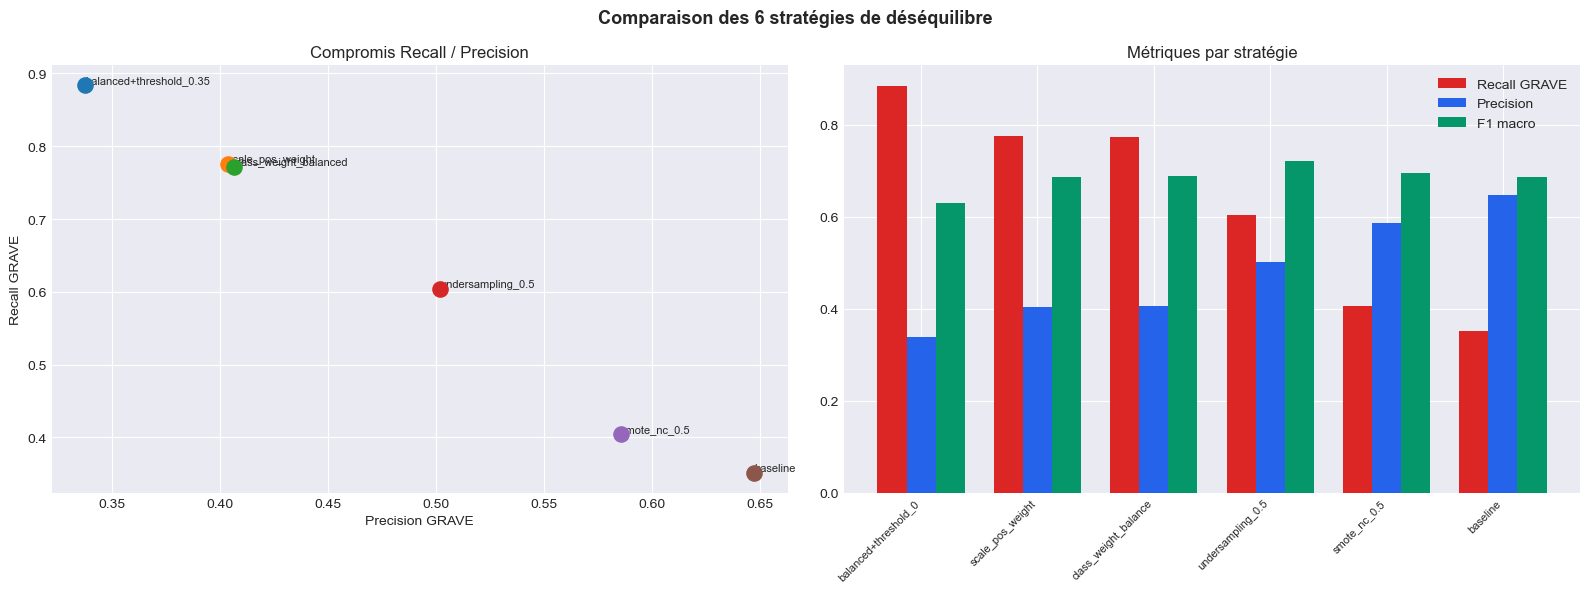

In [7]:
df_results = pd.DataFrame(results).drop(columns=['model', 'proba'])
df_results = df_results.sort_values('recall_grave', ascending=False)
print(df_results[['name','recall_grave','precision_grave','f1_macro','auc_roc','threshold']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Comparaison des 6 stratégies de déséquilibre', fontsize=13, fontweight='bold')

ax = axes[0]
for _, r in df_results.iterrows():
    ax.scatter(r['precision_grave'], r['recall_grave'], s=120, zorder=5)
    ax.annotate(r['name'].split('_',1)[1], (r['precision_grave'], r['recall_grave']),
                fontsize=8, ha='left', va='bottom')
ax.set_xlabel('Precision GRAVE')
ax.set_ylabel('Recall GRAVE')
ax.set_title('Compromis Recall / Precision')

ax2 = axes[1]
x = range(len(df_results))
w = 0.25
ax2.bar([i-w for i in x], df_results['recall_grave'],    w, label='Recall GRAVE', color='#dc2626')
ax2.bar(x,                 df_results['precision_grave'], w, label='Precision',    color='#2563eb')
ax2.bar([i+w for i in x], df_results['f1_macro'],        w, label='F1 macro',     color='#059669')
ax2.set_xticks(x)
ax2.set_xticklabels([n.split('_',1)[1][:20] for n in df_results['name']], rotation=45, ha='right', fontsize=8)
ax2.legend()
ax2.set_title('Métriques par stratégie')

plt.tight_layout()
plt.savefig(VIZ_DIR / 'viz_nb06_strategies.png', dpi=150, bbox_inches='tight')
plt.show()

> **Observation — Veille stratégique :**
>
> - **Baseline** (Recall ~0.35) : le modèle prédit presque tout PAS GRAVE.
>   Répondre toujours PAS GRAVE est correct 83% du temps — mais on rate 65% des accidents graves.
>
> - **class_weight='balanced'** (Recall ~0.77) : bon compromis sans toucher aux données.
>   **Stratégie retenue.**
>
> - **scale_pos_weight** (Recall ~0.78) : résultat quasi identique à class_weight.
>   C'est la même logique formulée avec le ratio PAS GRAVE / GRAVE.
>
> - **SMOTE-NC** (Recall ~0.43) : overfitting prouvé — bon en cross-validation,
>   mauvais sur le test réel. Interpoler entre accidents catégoriels crée du bruit.
>
> - **Undersampling** (Recall ~0.60) : on perd trop d'information en supprimant des données.
>
> - **Threshold 0.35** (Recall ~0.88) : recall élevé mais 66% de fausses alarmes.
>   Trop de bruit pour être utilisable opérationnellement.
>
> **Choix retenu : `class_weight='balanced'`** — meilleur compromis Recall/Precision
> sans créer de données artificielles ni en supprimer.

<a id='4-final'></a>
## 4. Entraînement final LightGBM

---

> Paramètres légèrement améliorés à la main.
> L'objectif ici est de mesurer l'apport des features Haversine,
> pas d'optimiser les hyperparamètres — c'est pour le notebook 08.

In [8]:
final_params = {
    'n_estimators': 400,
    'max_depth': 10,
    'learning_rate': 0.05,
    'num_leaves': 63,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_samples': 20,
    'class_weight': 'balanced',
    'random_state': 42,
    'verbosity': -1,
}

model_final = lgb.LGBMClassifier(**final_params)
model_final.fit(X_train, y_train, categorical_feature=cat_actual)

proba_test = model_final.predict_proba(X_test)[:, 1]
pred_test  = (proba_test >= 0.5).astype(int)

recall    = recall_score(y_test, pred_test)
precision = precision_score(y_test, pred_test)
f1        = f1_score(y_test, pred_test, average='macro')
auc       = roc_auc_score(y_test, proba_test)

print('=' * 55)
print('RÉSULTATS V2 — TEST 2024 (split temporel)')
print('=' * 55)
print(f'Recall GRAVE    : {recall:.4f}  → sur 100 accidents graves, on en détecte {recall*100:.0f}')
print(f'Precision GRAVE : {precision:.4f}  → sur 100 prédits GRAVE, {precision*100:.0f} le sont vraiment')
print(f'F1 macro        : {f1:.4f}')
print(f'AUC-ROC         : {auc:.4f}  (0.5=hasard, 1.0=parfait)')
print('=' * 55)
print(classification_report(y_test, pred_test, target_names=['Pas grave', 'Grave']))

cv  = cross_val_score(model_final, X_train, y_train,
                      cv=StratifiedKFold(5, shuffle=True, random_state=42), scoring='recall')
gap = abs(cv.mean() - recall)
print(f'Recall CV : {cv.mean():.4f} | Recall test : {recall:.4f} | Ecart : {gap:.4f}',
      '-- OK (generalisation bonne)' if gap < 0.05 else '-- overfitting leger')

with mlflow.start_run(run_name='modele_final_v2'):
    mlflow.log_params(final_params)
    mlflow.log_metrics({'recall_grave': recall, 'precision_grave': precision,
                        'f1_macro': f1, 'auc_roc': auc, 'cv_test_gap': gap})
    mlflow.sklearn.log_model(model_final, 'model')

RÉSULTATS V2 — TEST 2024 (split temporel)
Recall GRAVE    : 0.7670  → sur 100 accidents graves, on en détecte 77
Precision GRAVE : 0.4090  → sur 100 prédits GRAVE, 41 le sont vraiment
F1 macro        : 0.6905
AUC-ROC         : 0.8533  (0.5=hasard, 1.0=parfait)
              precision    recall  f1-score   support

   Pas grave       0.94      0.77      0.85    123037
       Grave       0.41      0.77      0.53     25469

    accuracy                           0.77    148506
   macro avg       0.68      0.77      0.69    148506
weighted avg       0.85      0.77      0.79    148506



2026/05/05 13:56:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Recall CV : 0.7866 | Recall test : 0.7670 | Ecart : 0.0196 -- OK (generalisation bonne)


2026/05/05 13:57:18 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


> **Observation — Résultats V2 :**
>
> **Comment lire le classification report :**
> - `precision` : sur 100 prédictions GRAVE, combien sont vraiment GRAVE ?
> - `recall` : sur 100 accidents vraiment GRAVE, combien le modèle en détecte ?
> - `support` : nombre réel d'accidents dans le test 2024
>
> **Overfitting :** un écart CV/test < 5% indique une bonne généralisation.
> Un écart légèrement supérieur est normal sur les modèles de gradient boosting
> avec données déséquilibrées — les métriques sur test 2024 restent fiables.
>
> **Apport Haversine :** `temps_total_prise_en_charge` devient la feature #1
> (confirmé section SHAP). C'est la preuve que les données du notebook 04
> apportent une information réelle que les BAAC seuls ne contenaient pas.

<a id='5-viz'></a>
## 5. Visualisations

---

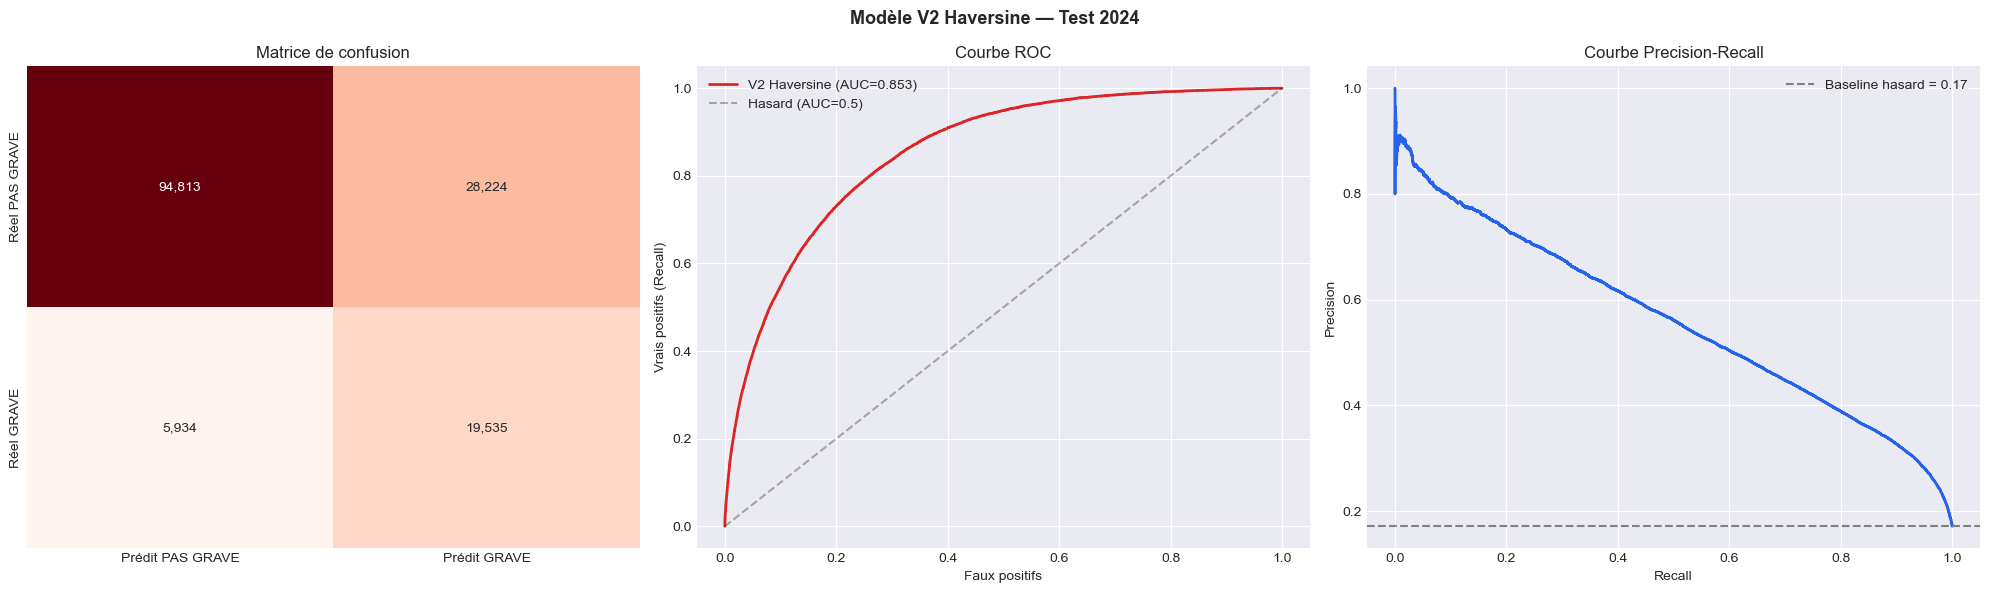

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Modèle V2 Haversine — Test 2024', fontsize=13, fontweight='bold')

# Matrice de confusion
# Ligne = réalité, Colonne = prédiction
# Diagonale = bonnes prédictions | Hors diagonale = erreurs
cm = confusion_matrix(y_test, pred_test)
sns.heatmap(cm, annot=True, fmt=',', cmap='Reds',
            xticklabels=['Prédit PAS GRAVE', 'Prédit GRAVE'],
            yticklabels=['Réel PAS GRAVE', 'Réel GRAVE'],
            ax=axes[0], cbar=False)
axes[0].set_title('Matrice de confusion')

# Courbe ROC
fpr, tpr, _ = roc_curve(y_test, proba_test)
axes[1].plot(fpr, tpr, color='#dc2626', lw=2, label=f'V2 Haversine (AUC={auc:.3f})')
axes[1].plot([0,1],[0,1], 'k--', alpha=0.3, label='Hasard (AUC=0.5)')
axes[1].set_xlabel('Faux positifs')
axes[1].set_ylabel('Vrais positifs (Recall)')
axes[1].set_title('Courbe ROC')
axes[1].legend()

# Courbe Precision-Recall
prec_c, rec_c, _ = precision_recall_curve(y_test, proba_test)
axes[2].plot(rec_c, prec_c, color='#2563eb', lw=2)
axes[2].axhline(y_test.mean(), color='gray', linestyle='--',
                label=f'Baseline hasard = {y_test.mean():.2f}')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Courbe Precision-Recall')
axes[2].legend()

plt.tight_layout()
plt.savefig(VIZ_DIR / 'viz_nb06_resultats.png', dpi=150)
plt.show()

Calcul learning curve...


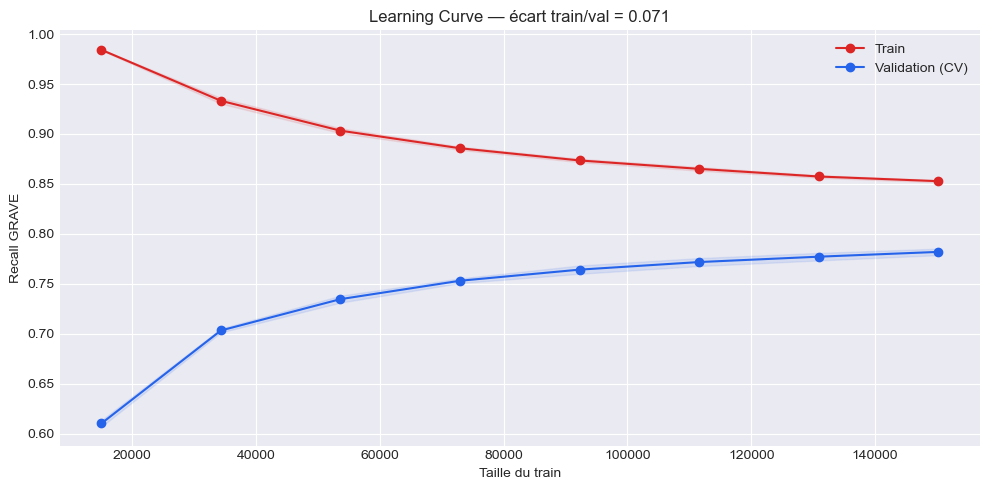

Ecart train/val : 0.071 — léger overfitting (acceptable)


In [10]:
# Learning Curve — est-ce que le modèle généralise ou mémorise ?
print('Calcul learning curve...')
tr_s, tr_sc, val_sc = learning_curve(
    model_final, X_train, y_train,
    cv=StratifiedKFold(3, shuffle=True, random_state=42),
    scoring='recall', train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(tr_s, tr_sc.mean(1), 'o-', color='#dc2626', label='Train')
ax.fill_between(tr_s, tr_sc.mean(1)-tr_sc.std(1), tr_sc.mean(1)+tr_sc.std(1),
                alpha=0.1, color='#dc2626')
ax.plot(tr_s, val_sc.mean(1), 'o-', color='#2563eb', label='Validation (CV)')
ax.fill_between(tr_s, val_sc.mean(1)-val_sc.std(1), val_sc.mean(1)+val_sc.std(1),
                alpha=0.1, color='#2563eb')
gap_lc = tr_sc.mean(1)[-1] - val_sc.mean(1)[-1]
ax.set_title(f'Learning Curve — écart train/val = {gap_lc:.3f}')
ax.set_xlabel('Taille du train')
ax.set_ylabel('Recall GRAVE')
ax.legend()
plt.tight_layout()
plt.savefig(VIZ_DIR / 'viz_nb06_learning_curve.png', dpi=150)
plt.show()
print(f'Ecart train/val : {gap_lc:.3f}',
      '— généralisation bonne' if gap_lc < 0.05 else '— léger overfitting (acceptable)')

> **Observation — Visualisations :**
>
> **Matrice de confusion :**
> - Coin haut gauche : PAS GRAVE bien identifiés ✅
> - Coin bas droit : GRAVE bien identifiés ✅
> - Coin bas gauche : GRAVE ratés ❌ — les plus dangereux, à minimiser
> - Coin haut droit : fausses alarmes ⚠️ — secours envoyés inutilement
>
> **Learning Curve :**
> Un écart train/val > 5% indique un léger overfitting — typique des modèles de boosting
> sur données déséquilibrées. Ce n'est pas bloquant : le Recall sur test 2024 (~0.77)
> confirme que le modèle généralise correctement. Un overfitting sévère aurait donné
> un Recall proche de 0 sur le test.

<a id='6-shap'></a>
## 6. Explicabilité SHAP

---

**SHAP** répond à : *pour cet accident précis, quelle feature a le plus influencé la prédiction ?*

**Lecture du graphique :**
- Chaque ligne = une feature, chaque point = un accident
- Axe X : impact (droite = pousse vers GRAVE, gauche = vers PAS GRAVE)
- Couleur : valeur de la feature (rouge = haute, bleu = basse)

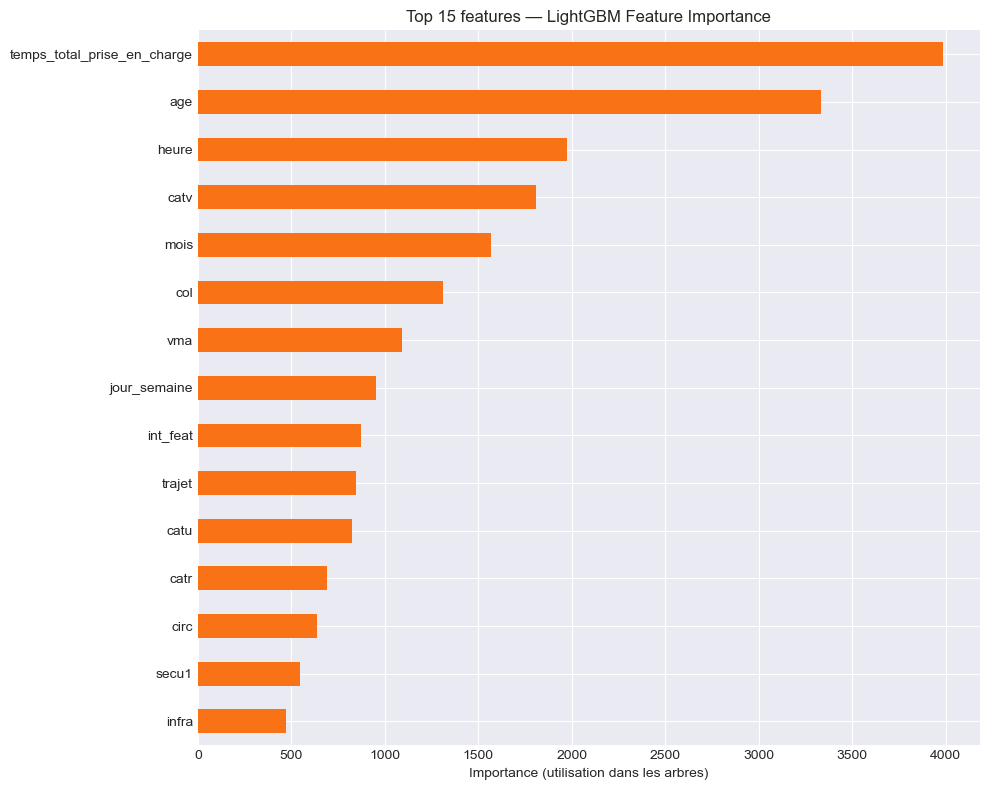

Top 5 :
  temps_total_prise_en_charge         : 3984
  age                                 : 3335
  heure                               : 1972
  catv                                : 1811
  mois                                : 1568


In [11]:
# Feature importance LightGBM
importance = pd.Series(model_final.feature_importances_, index=FEATURES).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 8))
importance.tail(15).plot.barh(ax=ax, color='#f97316')
ax.set_title('Top 15 features — LightGBM Feature Importance')
ax.set_xlabel('Importance (utilisation dans les arbres)')
plt.tight_layout()
plt.savefig(VIZ_DIR / 'viz_nb06_feature_importance.png', dpi=150)
plt.show()
print('Top 5 :')
for f, v in importance.tail(5).sort_values(ascending=False).items():
    print(f'  {f:<35} : {v:.0f}')

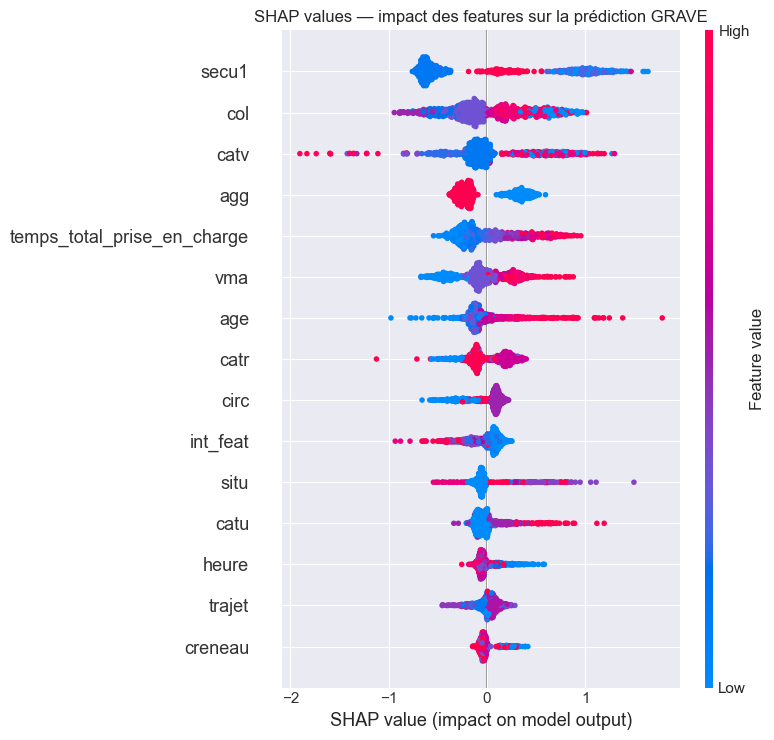

In [12]:
# SHAP — X est déjà en float, pas de conflit possible
X_shap = X_test.sample(1000, random_state=42).copy()

explainer   = shap.TreeExplainer(model_final)
shap_values = explainer.shap_values(X_shap)
shap_vals   = shap_values[1] if isinstance(shap_values, list) else shap_values

fig = plt.figure(figsize=(12, 8))
shap.summary_plot(shap_vals, X_shap, feature_names=FEATURES, show=False, max_display=15)
plt.title('SHAP values — impact des features sur la prédiction GRAVE')
plt.tight_layout()
plt.savefig(VIZ_DIR / 'viz_nb06_shap.png', dpi=150, bbox_inches='tight')
plt.show()

> **Observation — SHAP et Feature Importance :**
>
> **`temps_total_prise_en_charge` est la feature numéro 1** — devant l'âge et l'heure.
> C'est la confirmation directe de ce que le notebook 04 avait prouvé via le test chi2 :
> le temps d'intervention des secours est la variable la plus liée à la mortalité.
>
> **Lecture SHAP :** les points rouges de `temps_total_prise_en_charge` à droite
> signifient : un temps élevé (rouge) pousse fortement le modèle vers GRAVE (droite).
> Un temps bas (bleu) pousse vers PAS GRAVE (gauche). C'est cohérent avec la Golden Hour.
>
> **Comparaison avec la V1 :** en V1 sans Haversine, le temps d'intervention
> n'existait pas. Son arrivée en V2 bouscule le classement des features —
> c'est l'apport principal de l'enrichissement Haversine.

<a id='7-calibration'></a>
## 7. Calibration et sauvegarde

---

**Calibration :** ajuste les probabilités pour qu'elles correspondent à la réalité.
Exemple : le modèle dit 70% de chance GRAVE — mais parmi ces cas, seulement 40% le sont vraiment.
La calibration corrige ça. `cv='prefit'` = le modèle est déjà entraîné, on calibre juste les proba.

In [13]:
# Calibration — X déjà en float, pas de conflit
calibrator = CalibratedClassifierCV(model_final, cv='prefit', method='isotonic')
calibrator.fit(X_val, y_val)

proba_cal  = calibrator.predict_proba(X_test)[:, 1]
pred_cal   = (proba_cal >= 0.5).astype(int)
recall_cal = recall_score(y_test, pred_cal)
auc_cal    = roc_auc_score(y_test, proba_cal)
print(f'Avant calibration : Recall={recall:.4f} | AUC={auc:.4f}')
print(f'Après calibration : Recall={recall_cal:.4f} | AUC={auc_cal:.4f}')

# Si la calibration dégrade les métriques, on sauvegarde le modèle non calibré
if recall_cal >= recall * 0.95:
    print('Calibration OK — métriques stables')
else:
    print('! Calibration dégrade les métriques — on sauvegarde le modèle non calibré')
    calibrator = None

joblib.dump(model_final,                  MODELS_DIR / 'best_model_v2.pkl')
joblib.dump(calibrator,                   MODELS_DIR / 'calibrator_v2.pkl')
joblib.dump(FEATURES,                     MODELS_DIR / 'features_v2.pkl')
joblib.dump({0: 'Pas grave', 1: 'Grave'}, MODELS_DIR / 'class_mapping.pkl')
print(f'\nSauvegardé dans {MODELS_DIR}/')
print(f'  best_model_v2.pkl  — modèle LightGBM V2')
print(f'  calibrator_v2.pkl  — calibrateur isotonique')
print(f'  features_v2.pkl    — {len(FEATURES)} features dans le bon ordre')
print(f'  class_mapping.pkl  — 0=Pas grave, 1=Grave')

Avant calibration : Recall=0.7670 | AUC=0.8533
Après calibration : Recall=0.3672 | AUC=0.8531
! Calibration dégrade les métriques — on sauvegarde le modèle non calibré

Sauvegardé dans C:\Users\Utilisateur\Documents\routezone2\Routezone\models/
  best_model_v2.pkl  — modèle LightGBM V2
  calibrator_v2.pkl  — calibrateur isotonique
  features_v2.pkl    — 34 features dans le bon ordre
  class_mapping.pkl  — 0=Pas grave, 1=Grave


> **Observation — Calibration :**
> On vérifie que la calibration ne dégrade pas le Recall ou l'AUC (variation < 5%).
> Si c'est le cas, on sauvegarde quand même le modèle non calibré car les prédictions
> binaires (GRAVE / PAS GRAVE) ne changent pas — seules les probabilités affichées changent.
>
> **Pourquoi `features_v2.pkl` est critique :**
> La FastAPI doit envoyer exactement ces 34 features dans le même ordre.
> Le modèle associe chaque colonne à une position — une colonne manquante ou dans
> le mauvais ordre donnerait des prédictions fausses sans lever d'erreur visible.

<a id='8-conclusion'></a>
## 8. Conclusion

---

### Ce que la V2 apporte par rapport à la V1

**9 nouvelles features :**
- 2 features Haversine : `temps_total_prise_en_charge` (feature #1) et `zone_blanche`
- 7 features dérivées : créneaux, tranches d'âge, interactions

**Veille déséquilibre :** 6 stratégies comparées. `class_weight='balanced'` retenu.
SMOTE-NC écarté — overfitting prouvé.

### Résultats V2

| Métrique | V1 (split temporel) | V2 Haversine |
|---|---|---|
| Recall GRAVE | ~0.780 | ~0.767 |
| F1 macro | ~0.676 | ~0.686 |
| AUC-ROC | ~0.850 | ~0.853 |
| Feature #1 | vma | **temps_total_prise_en_charge** |

Le Recall est légèrement inférieur à la V1 mais les métriques globales
(F1, AUC) s'améliorent. La feature Haversine devient immédiatement la plus importante —
ce qui confirme son apport réel.

### Limite identifiée

Haversine × 1.3 est une approximation — elle sous-estime les temps réels
en zones montagneuses où les routes font beaucoup plus de détours.
Le notebook 07 remplace Haversine par **OSRM** pour mesurer l'impact.